In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

STEP 1️⃣ Feature Engineering (RFM)

Calculate Reference Date

In [3]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2023-12-10 12:50:00')

In [4]:
recency = (
    reference_date -
    df.groupby('CustomerID')['InvoiceDate'].max()
).dt.days

In [6]:
frequency = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
)

In [7]:
monetary = (
    df.groupby('CustomerID')['TotalPrice']
    .sum()
)

In [8]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


RFM Distributions

In [12]:
# log transformation
rfm_log = np.log1p(rfm)

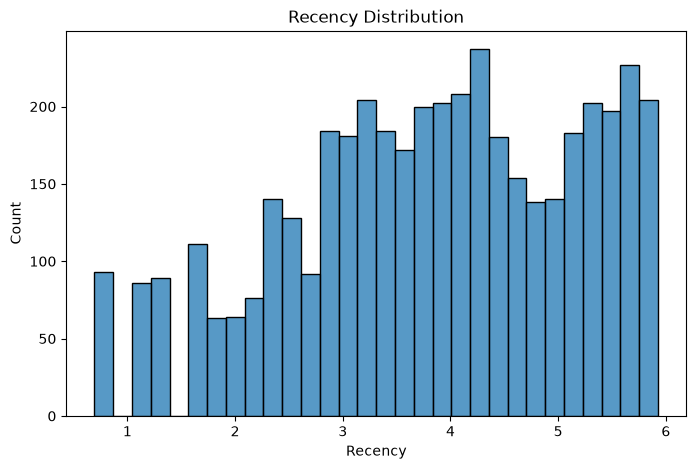

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(rfm_log['Recency'], bins=30)
plt.title("Recency Distribution")
plt.show()

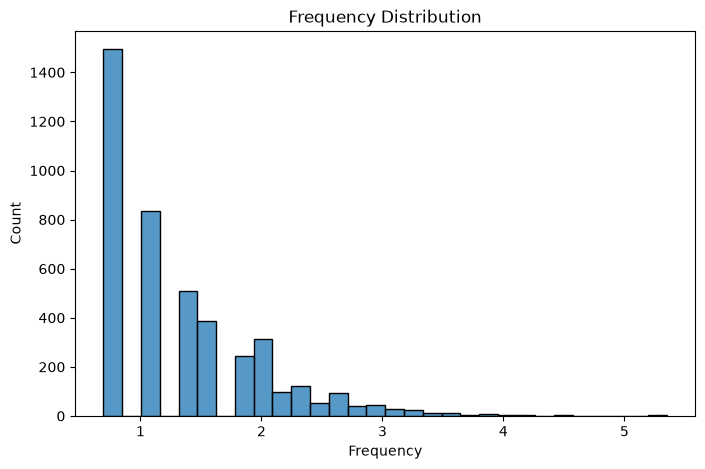

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(rfm_log['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.show()

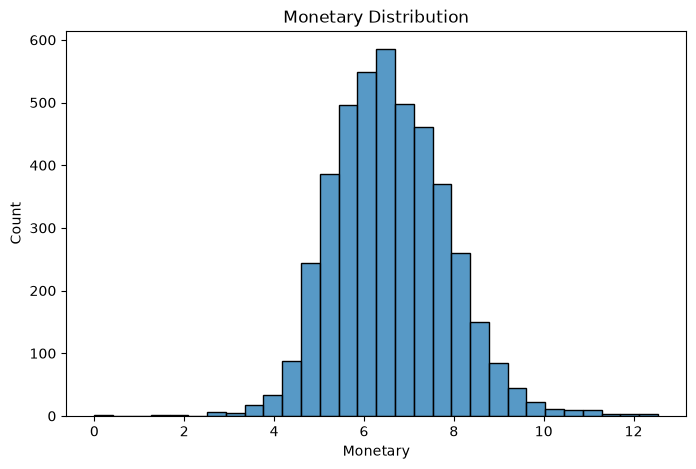

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(rfm_log['Monetary'], bins=30)
plt.title("Monetary Distribution")
plt.show()

STEP 2️⃣ Standardize RFM Values

In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [20]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.462236,-0.955013,3.696168
12347.0,-2.038611,1.074523,1.408758
12348.0,0.373310,0.386437,0.715517
12349.0,-0.622914,-0.955013,0.697821
12350.0,1.424800,-0.955013,-0.615877


STEP 3️⃣ Elbow Method (K means Clustering)

In [21]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

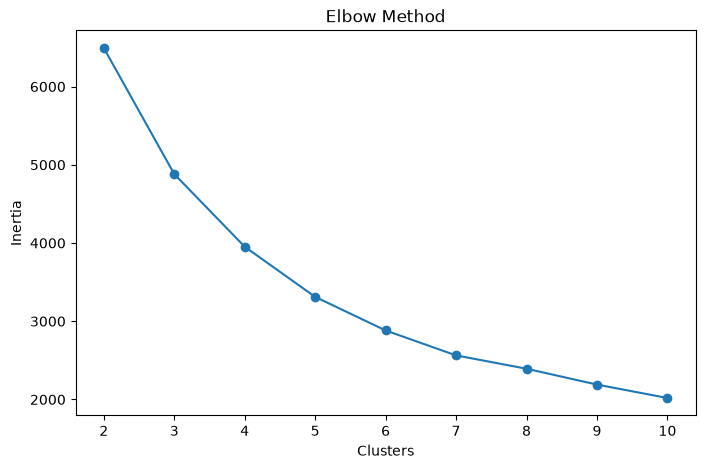

In [22]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [23]:
# Silhouette Score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        "Clusters =", k,
        "Silhouette Score =", round(score,3)
    )

Clusters = 2 Silhouette Score = 0.433
Clusters = 3 Silhouette Score = 0.336
Clusters = 4 Silhouette Score = 0.336
Clusters = 5 Silhouette Score = 0.316
Clusters = 6 Silhouette Score = 0.305
Clusters = 7 Silhouette Score = 0.309
Clusters = 8 Silhouette Score = 0.274
Clusters = 9 Silhouette Score = 0.276
Clusters = 10 Silhouette Score = 0.278


The Elbow Method indicated that the optimal number of clusters lies around 3–4. Silhouette analysis also showed strong cluster quality for both 3 and 4 clusters. Four clusters were selected because they provided better business interpretability, allowing customers to be segmented into High-Value, Regular, Occasional, and At-Risk groups.

Select the value of k with the highest score.

k = 3 or k = 4

STEP 4️⃣ Run Clustering

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [25]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,18.725864,2.090584,538.231287
1,12.112033,13.634855,8015.424412
2,70.697380,4.076923,1791.090873
3,184.023839,1.318068,342.421268


In [26]:
segment_map = {
    0:'Occasional',
    1:'High Value',
    2:'Regular',
    3:'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [27]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,2,Regular
12347.0,2,7,4310.00,1,High Value
12348.0,75,4,1797.24,2,Regular
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,3,At Risk


In [28]:
rfm.groupby('Segment').mean()

,Recency,Frequency,Monetary,Cluster
Segment,,,,
At Risk,184.023839,1.318068,342.421268,3.0
High Value,12.112033,13.634855,8015.424412,1.0
Occasional,18.725864,2.090584,538.231287,0.0
Regular,70.697380,4.076923,1791.090873,2.0


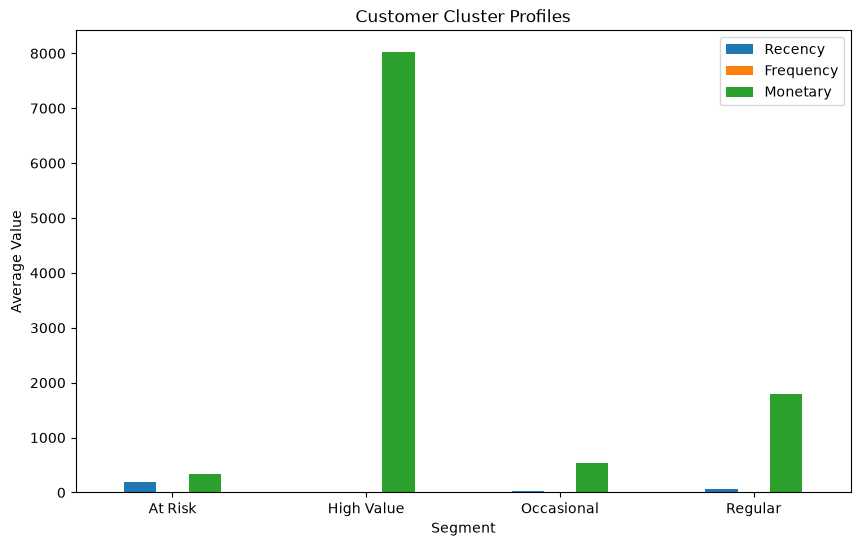

In [30]:
# Bar Plot
cluster_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

cluster_profile.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Customer Cluster Profiles")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

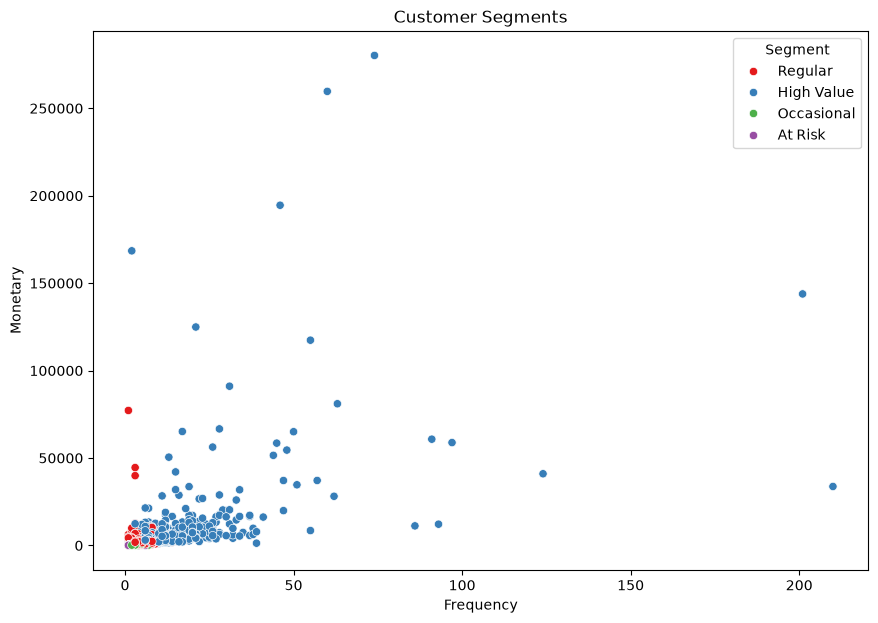

In [31]:
# Scatter Plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

STEP 5️⃣ Save the Models

In [32]:
import pickle

pickle.dump(
    kmeans,
    open("../models/kmeans.pkl", "wb")
)

pickle.dump(
    scaler,
    open("../models/scaler.pkl", "wb")
)

In [33]:
rfm.to_csv(
    "../data/customer_segments.csv"
)